# Reproducible Data Workflow for Video Game Sales, Ratings, and Genre Trends

**Student:** Robert Mayfield  
**Project:** AI Programming Foundations - Udacity AI MBA Capstone  
**Dataset:** Video Game Sales, Ratings, and Genre Data

## 1. Project Overview

This project focuses on building a clean, reusable, and reproducible data workflow using Python, Pandas, NumPy, Matplotlib, and Seaborn. The `Video Game Sales and Ratings` dataset contains video game market information such as game titles, platforms, genres, publishers, sales figures, ratings, and review scores. The goal is to clean and explore the dataset, create meaningful visualizations, and summarize insights that help establish industry context for a future AI-assisted projects meant to assist game developers in building better and more efficient products.

### Core Question

What patterns in video game genre, platform, sales, and ratings data can inform the design focus of an AI assisted game development tool?

## 2. Setup

The following imports cover the full project: standard library utilities, data processing libraries, visualization libraries, and the reusable functions from `src/`.

In [48]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.inspection import inspect_dataframe
from src.cleaning import clean_column_names, clean_score_columns, handle_missing_values
from src.eda import summarize_game_market

## 3. Data Ingestion

The dataset is stored as a zip archive at `data/raw/video-game-sales-ratings-data.zip` and contains a single CSV file, `Video_Games.csv`. The data is loaded directly from the archive without extracting to disk, keeping the raw data directory clean and the workflow self contained.

In [49]:
ZIP_PATH = '../data/raw/video-game-sales-ratings-data.zip'
CSV_NAME = 'Video_Games.csv'

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    with z.open(CSV_NAME) as f:
        df = pd.read_csv(f, index_col=0)

df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
index,,,,,,,,,,,,,,,,
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Initial Dataset Inspection

Before cleaning or analysis, we run a full inspection of the dataset to understand its structure, identify missing values, spot duplicates, and get a sense of the distributions across numeric and categorical columns. The `inspect_dataframe` function from `src/inspection.py` packages these steps into a single reusable call.

In [50]:
inspect_dataframe(df)

SHAPE AND STRUCTURE
------------------------------------------------------------
Rows:    16,928
Columns: 16

COLUMN NAMES AND DATA TYPES
------------------------------------------------------------
Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score          object
User_Count         float64
Developer           object
Rating              object

MEMORY USAGE
------------------------------------------------------------
Total: 8.19 MB

MISSING VALUES
------------------------------------------------------------
                 Null Count  Null %
User_Count             9210   54.41
Critic_Count           8668   51.21
Critic_Score           8668   51.21
Rating                 6836   40.38
User_Score            

### Inspection Notes

**Shape and Structure:** The dataset contains 16,928 rows and 16 columns. Columns cover game titles, platforms, release years, genres, publishers, four regional sales figures, global sales, critic and user review scores, developer names, and ESRB ratings. Total memory footprint is 8.19 MB.

**Data Types:** All sales and score columns load as float64 except `User_Score`, which loads as object. The categorical describe output reveals why: the most frequent value in `User_Score` is `tbd`, a placeholder used when a user score is not yet available. This string presence prevents pandas from inferring a numeric type. `Year_of_Release` also loads as float64 rather than integer, likely due to missing values in that column. Both will be addressed during cleaning.

**Missing Values:** The dataset has substantial missingness concentrated in review related columns. `User_Count` is missing for 9,210 records (54.41%), `Critic_Count` and `Critic_Score` are each missing for 8,668 records (51.21%), and `Rating`, `User_Score`, and `Developer` are missing for roughly 40% of records each. This pattern is consistent across the dataset: older and lower profile titles were frequently not reviewed by critics or users. `Year_of_Release` is missing for 273 records (1.61%), `Publisher` for 55 (0.32%), and `Name` and `Genre` for just 2 records each (0.01%). The review column gaps are significant enough that any analysis involving scores will be working with roughly half the dataset.

**Duplicate Rows:** 209 duplicate rows are present and will be removed during cleaning.

**Numeric Distributions:** Sales figures are heavily right skewed across all regions. The median global sales figure is 0.17 million units while the maximum is 82.53 million, and the 75th percentile sits at just 0.49 million. The vast majority of titles sell modestly, with a small number of blockbusters driving the upper range. `Critic_Score` ranges from 13 to 98 with a mean of 69, suggesting most reviewed titles cluster in the average to good range. `User_Count` has an extreme distribution with a mean of 163 but a maximum of 10,665 and a large standard deviation, indicating that a handful of titles attract enormous user review volume while most receive very few. Release years span 1980 to 2020 with a mean of 2006.5, reflecting that the bulk of the dataset covers the mid-2000s peak of the disc-based console era.

**Categorical Summaries:** There are 31 unique platforms in the dataset, with PS2 being the most represented at 2,188 titles. Genre has only 12 unique values, with Action being the most common at 3,410 titles. Publisher has 581 unique values, with Electronic Arts appearing most frequently at 1,389 titles. Developer has 1,696 unique values. Rating has 8 unique values with E (Everyone) being the most common at 4,043 titles, followed by other ESRB categories.

**Sample Data:** The first rows confirm the dataset is sorted by global sales descending, with Nintendo titles dominating the top. The last rows show titles clustered around 0.6 million in global sales, and several are missing review data entirely, consistent with the missing value patterns described above.

### Extended Missingness Analysis

The high missingness in review columns warrants a closer look before making cleaning decisions. The following cells examine whether gaps are random or concentrated in specific years, platforms, or genres, and whether the review columns tend to go missing together.

#### Critic Score Missingness by Release Year

In [51]:
year_df = df.dropna(subset=['Year_of_Release']).copy()
year_df['Year_of_Release'] = year_df['Year_of_Release'].astype(int)

missing_by_year = (
    year_df.groupby('Year_of_Release')['Critic_Score']
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
    .reset_index()
    .rename(columns={'Critic_Score': 'Critic_Score_Missing_%'})
)

print(missing_by_year.to_string(index=False))

 Year_of_Release  Critic_Score_Missing_%
            1980                   100.0
            1981                   100.0
            1982                   100.0
            1983                   100.0
            1984                   100.0
            1985                    92.9
            1986                   100.0
            1987                   100.0
            1988                    93.3
            1989                   100.0
            1990                   100.0
            1991                   100.0
            1992                    97.7
            1993                   100.0
            1994                    99.2
            1995                   100.0
            1996                    97.0
            1997                    94.2
            1998                    92.2
            1999                    88.6
            2000                    59.0
            2001                    32.0
            2002                    24.1
            2003

#### Critic Score Missingness by Platform

In [52]:
missing_by_platform = (
    df.groupby('Platform')['Critic_Score']
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Critic_Score': 'Critic_Score_Missing_%'})
)

print(missing_by_platform.to_string(index=False))

Platform  Critic_Score_Missing_%
    2600                   100.0
     3DO                   100.0
      GB                   100.0
     NES                   100.0
     N64                   100.0
      GG                   100.0
     GEN                   100.0
    PCFX                   100.0
      NG                   100.0
     SCD                   100.0
      WS                   100.0
    SNES                   100.0
    TG16                   100.0
     SAT                   100.0
      PS                    83.2
      DC                    73.1
     PSV                    72.2
     3DS                    67.5
      DS                    66.7
     PSP                    61.8
     Wii                    55.6
     GBA                    46.4
     PS2                    39.8
    WiiU                    38.5
     PS3                    37.9
     PS4                    36.1
    XOne                    31.6
    X360                    27.2
      PC                    26.8
      GC  

#### Critic Score Missingness by Genre

In [53]:
missing_by_genre = (
    df.dropna(subset=['Genre']).groupby('Genre')['Critic_Score']
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Critic_Score': 'Critic_Score_Missing_%'})
)

print(missing_by_genre.to_string(index=False))

       Genre  Critic_Score_Missing_%
   Adventure                    75.3
        Misc                    69.9
      Puzzle                    61.5
  Simulation                    59.7
    Strategy                    55.9
    Fighting                    51.6
Role-Playing                    50.8
      Sports                    48.9
    Platform                    44.1
      Action                    43.9
      Racing                    40.5
     Shooter                    28.4


#### Records Missing Year of Release

In [54]:
missing_year = df[df['Year_of_Release'].isnull()]
print(f"Records missing Year_of_Release: {len(missing_year)}\n")
print(missing_year[['Name', 'Platform', 'Genre', 'Publisher', 'Global_Sales']].to_string())

Records missing Year_of_Release: 273

                                                                     Name Platform         Genre                               Publisher  Global_Sales
index                                                                                                                                                 
183                                                       Madden NFL 2004      PS2        Sports                         Electronic Arts          5.23
377                                                      FIFA Soccer 2004      PS2        Sports                         Electronic Arts          3.49
456                                            LEGO Batman: The Videogame      Wii        Action  Warner Bros. Interactive Entertainment          3.06
475                                            wwe Smackdown vs. Raw 2006      PS2      Fighting                                     NaN          3.00
609                                                     

#### Review Column Co-occurrence of Missingness

In [55]:
review_cols = ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating']

# How many review columns are missing per record
missing_per_record = df[review_cols].isnull().sum(axis=1).value_counts().sort_index()
print("Number of review columns missing per record:")
for n_missing, count in missing_per_record.items():
    pct = count / len(df) * 100
    print(f"  {n_missing} columns missing: {count:,} records ({pct:.1f}%)")

print()

# Do Critic_Score and User_Score tend to go missing together?
both_missing = df[df['Critic_Score'].isnull() & df['User_Score'].isnull()].shape[0]
critic_only  = df[df['Critic_Score'].isnull() & df['User_Score'].notna()].shape[0]
user_only    = df[df['Critic_Score'].notna()  & df['User_Score'].isnull()].shape[0]

print("Critic_Score and User_Score co-occurrence:")
print(f"  Both missing:          {both_missing:,}")
print(f"  Only Critic_Score missing: {critic_only:,}")
print(f"  Only User_Score missing:   {user_only:,}")

Number of review columns missing per record:
  0 columns missing: 7,063 records (41.7%)
  1 columns missing: 1,151 records (6.8%)
  2 columns missing: 603 records (3.6%)
  3 columns missing: 1,326 records (7.8%)
  4 columns missing: 76 records (0.4%)
  5 columns missing: 54 records (0.3%)
  6 columns missing: 6,655 records (39.3%)

Critic_Score and User_Score co-occurrence:
  Both missing:          6,731
  Only Critic_Score missing: 1,937
  Only User_Score missing:   38


### Extended Missingness Findings and Cleaning Decisions

**Missingness by release year** reveals a sharp and systematic pattern. Titles released before 2000 are almost entirely missing critic scores, with most years in the 1980s and 1990s at or near 100% missingness. The coverage improves dramatically around 2000 to 2001, dropping to 32% missing, which aligns with the rise of dedicated games journalism and online review aggregation. Missingness then climbs again in the later years of the dataset, reaching 100% for 2017 and 2020, which likely reflects incomplete data collection rather than a lack of reviews. The missingness is not random. It is a direct function of when structured review data became consistently available.

**Missingness by platform** reinforces this conclusion. Every retro and legacy platform (NES, SNES, N64, GB, GEN, 2600, and others) shows 100% missingness. Older platforms that straddle the pre and post review era such as PS1 (83.2%) and DC (73.1%) show high but not complete gaps. Portable platforms (PSV 72.2%, 3DS 67.5%, DS 66.7%, PSP 61.8%) show elevated missingness even in the modern era, suggesting that handheld titles received less consistent critical coverage than their console counterparts. The most modern, high profile platforms (XB 11.9%, GC 19.5%, PC 26.8%, X360 27.2%) have the lowest missingness.

**Missingness by genre** shows a wider spread than the year and platform patterns. Adventure (75.3%) and Misc (69.9%) genres are most affected, while Shooter (28.4%) has the lowest missingness. This likely reflects that shooter and action titles attracted more consistent critical attention while niche genres such as adventure and simulation received less formal review coverage.

**Co-occurrence of missingness** is the most important finding for the cleaning decision. The data is strongly bimodal: 41.7% of records have none of the six review columns missing, and 39.3% have all six missing. Only 18.9% of records fall somewhere in between. This means the dataset contains two largely distinct populations, well reviewed games with complete data and unreviewed games with no review data at all. Critic_Score and User_Score go missing almost entirely together: 6,731 records are missing both, while only 38 records have a User_Score but no Critic_Score.

**Records missing Year_of_Release** include recognizable titles such as Madden NFL 2004, FIFA Soccer 2004, and LEGO Batman, indicating these are real games with a data collection gap rather than erroneous entries. Since year is required for any time based analysis and only 273 records are affected (1.61%), dropping these rows is a reasonable and low impact decision.

---

**Cleaning Decisions**

Based on this analysis, the following decisions will guide the cleaning functions:

| Column(s) | Decision | Reasoning |
|---|---|---|
| Duplicate rows (209) | Drop | Exact duplicates add no information |
| `Name`, `Genre` (2 missing each) | Drop rows | Cannot analyze a game without a title or genre |
| `Publisher` (55 missing) | Drop rows | Small count, publisher needed for meaningful grouping |
| `Year_of_Release` (273 missing) | Drop rows | Required for time analysis, small percentage |
| `Critic_Score`, `Critic_Count`, `User_Score`, `User_Count`, `Developer`, `Rating` | Keep NaN | Missingness is systematic and era driven, not a data error. Dropping would eliminate nearly all pre 2000 titles and bias the dataset toward the modern era. Score based analyses will drop nulls at the point of use. |
| `User_Score` `tbd` values | Replace with NaN, convert to float | `tbd` is a placeholder, not a score |

## 5. Data Cleaning Functions

Three cleaning functions are defined in `src/cleaning.py` and applied in sequence below. Each function returns a copy of the DataFrame, preserving the raw data unchanged. The cleaning decisions applied here are documented and justified in the extended missingness analysis in Section 4.

- `clean_column_names` standardizes all column names to lowercase.
- `clean_score_columns` replaces `tbd` placeholder values in `user_score` with NaN and converts the column to float.
- `handle_missing_values` drops duplicate rows and rows missing values in essential columns, then converts `year_of_release` to integer.

In [56]:
rows_before = len(df)

df_clean = clean_column_names(df)
df_clean = clean_score_columns(df_clean)
df_clean = handle_missing_values(df_clean)

rows_after = len(df_clean)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {rows_after:,}")
print(f"Rows removed:         {rows_before - rows_after:,}")
print()
print(f"Columns: {list(df_clean.columns)}")
print(f"user_score dtype: {df_clean['user_score'].dtype}")
print(f"year_of_release dtype: {df_clean['year_of_release'].dtype}")

Rows before cleaning: 16,928
Rows after cleaning:  16,416
Rows removed:         512

Columns: ['name', 'platform', 'year_of_release', 'genre', 'publisher', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'global_sales', 'critic_score', 'critic_count', 'user_score', 'user_count', 'developer', 'rating']
user_score dtype: float64
year_of_release dtype: int64


In [57]:
df_clean.head()

,name,platform,year_of_release,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,critic_score,critic_count,user_score,user_count,developer,rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


#### Cleaning Verification

In [58]:
checks = {
    "No duplicate rows":                df_clean.duplicated().sum() == 0,
    "No nulls in name":                 df_clean['name'].isnull().sum() == 0,
    "No nulls in genre":                df_clean['genre'].isnull().sum() == 0,
    "No nulls in publisher":            df_clean['publisher'].isnull().sum() == 0,
    "No nulls in year_of_release":      df_clean['year_of_release'].isnull().sum() == 0,
    "user_score is float64":            df_clean['user_score'].dtype == 'float64',
    "year_of_release is int64":         df_clean['year_of_release'].dtype == 'int64',
    "No 'tbd' values in user_score":    'tbd' not in df_clean['user_score'].astype(str).values,
    "All column names are lowercase":   all(c == c.lower() for c in df_clean.columns),
}

all_passed = True
for check, result in checks.items():
    status = "PASS" if result else "FAIL"
    if not result:
        all_passed = False
    print(f"  [{status}] {check}")

print()
print("All checks passed." if all_passed else "One or more checks failed.")

  [PASS] No duplicate rows
  [PASS] No nulls in name
  [PASS] No nulls in genre
  [PASS] No nulls in publisher
  [PASS] No nulls in year_of_release
  [PASS] user_score is float64
  [PASS] year_of_release is int64
  [PASS] No 'tbd' values in user_score
  [PASS] All column names are lowercase

All checks passed.


#### Save Cleaned Dataset

In [59]:
PROCESSED_PATH = '../data/processed/video_games_clean.csv'

df_clean.to_csv(PROCESSED_PATH, index=False)

print(f"Cleaned dataset saved to {PROCESSED_PATH}")
print(f"Shape: {df_clean.shape}")

Cleaned dataset saved to ../data/processed/video_games_clean.csv
Shape: (16416, 16)


### Cleaning Notes

**Rows removed:** The pipeline removed 512 rows total, reducing the dataset from 16,928 to 16,416. The 512 reflects the combined effect of dropping 209 duplicate rows and dropping rows missing essential field values across name, genre, publisher, and year_of_release, with some rows satisfying more than one removal condition.

**Column names:** All 16 column names are now lowercase, making them consistent and easier to reference throughout the rest of the notebook.

**user_score:** The column is now float64. The `tbd` placeholder values have been replaced with NaN and the column successfully converted from object to numeric.

**year_of_release:** Now int64. The conversion is safe because all rows with a missing year were dropped before the cast, eliminating the fractional representation that float requires for nullable integers.

**Review columns retained:** `critic_score`, `critic_count`, `user_score`, `user_count`, `developer`, and `rating` retain their NaN values. As established in the missingness analysis, these gaps are systematic and era driven. Analyses that require score data will filter to non-null rows at the point of use rather than discarding this data globally.

## 6. Exploratory Analysis Function

The exploratory analysis is organized around seven questions that connect directly to the core question: what patterns in genre, platform, sales, and ratings data can inform the design focus of an AI-assisted game development tool?

The `summarize_game_market` function in `src/eda.py` handles grouped aggregations that are reusable across future projects. Each question includes a tabular summary, a supporting chart, and an interpretation of the findings.

In [60]:
summaries = summarize_game_market(df_clean)

#### Q1: Which genres are most represented in the dataset?

In [61]:
print(summaries['genre_counts'].to_string())

              game_count  total_global_sales  mean_global_sales
genre                                                          
Action              3307             1717.62               0.52
Sports              2306             1310.39               0.57
Misc                1697              783.19               0.46
Role-Playing        1483              930.90               0.63
Shooter             1296             1041.83               0.80
Adventure           1291              233.25               0.18
Racing              1225              723.69               0.59
Platform             878              825.86               0.94
Simulation           855              388.22               0.45
Fighting             837              442.63               0.53
Strategy             672              172.69               0.26
Puzzle               569              240.33               0.42


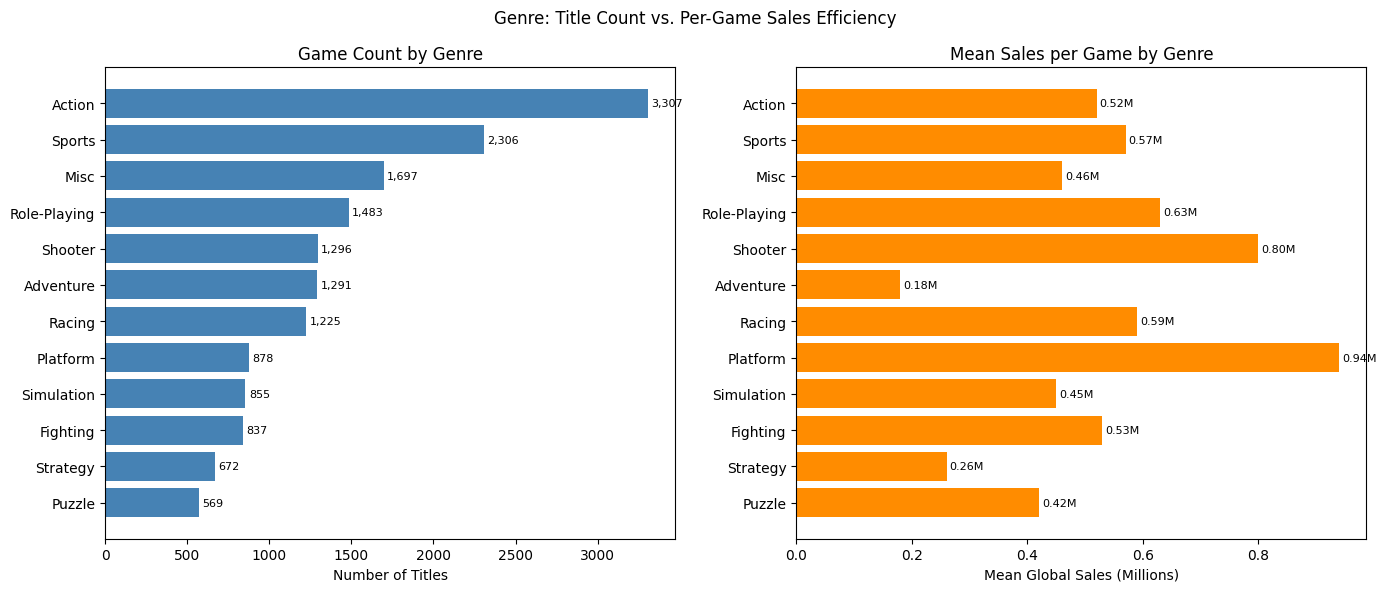

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

genre_data = summaries['genre_counts'].reset_index().sort_values('game_count')

axes[0].barh(genre_data['genre'], genre_data['game_count'], color='steelblue')
axes[0].set_xlabel('Number of Titles')
axes[0].set_title('Game Count by Genre')
for i, val in enumerate(genre_data['game_count']):
    axes[0].text(val + 20, i, f'{val:,}', va='center', fontsize=8)

axes[1].barh(genre_data['genre'], genre_data['mean_global_sales'], color='darkorange')
axes[1].set_xlabel('Mean Global Sales (Millions)')
axes[1].set_title('Mean Sales per Game by Genre')
for i, val in enumerate(genre_data['mean_global_sales']):
    axes[1].text(val + 0.005, i, f'{val:.2f}M', va='center', fontsize=8)

plt.suptitle('Genre: Title Count vs. Per-Game Sales Efficiency', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** Action is the dominant genre by title count at 3,307 games, nearly 43% more than the second largest genre, Sports at 2,306. Title count alone does not predict commercial efficiency. Platform titles average 0.94M in global sales each, the highest of any genre, while Action averages only 0.52M. Adventure has the lowest average at 0.18M despite 1,291 titles. These patterns show the market rewards genre selection differently from sheer volume, and the Platform genre's high revenue per release is a useful benchmark when evaluating design focus for a new title.

#### Q2: Which platforms are most represented in the dataset?

In [63]:
print(summaries['platform_counts'].to_string())

          game_count  total_global_sales  mean_global_sales
platform                                                   
PS2             2127             1233.46               0.58
DS              2122              803.73               0.38
PS3             1306              931.15               0.71
Wii             1286              891.74               0.69
X360            1232              961.39               0.78
PSP             1193              289.79               0.24
PS              1190              727.41               0.61
PC               952              256.21               0.27
XB               803              252.09               0.31
GBA              786              305.62               0.39
GC               542              197.14               0.36
3DS              512              257.92               0.50
PSV              429               53.82               0.13
PS4              393              314.23               0.80
N64              316              218.21

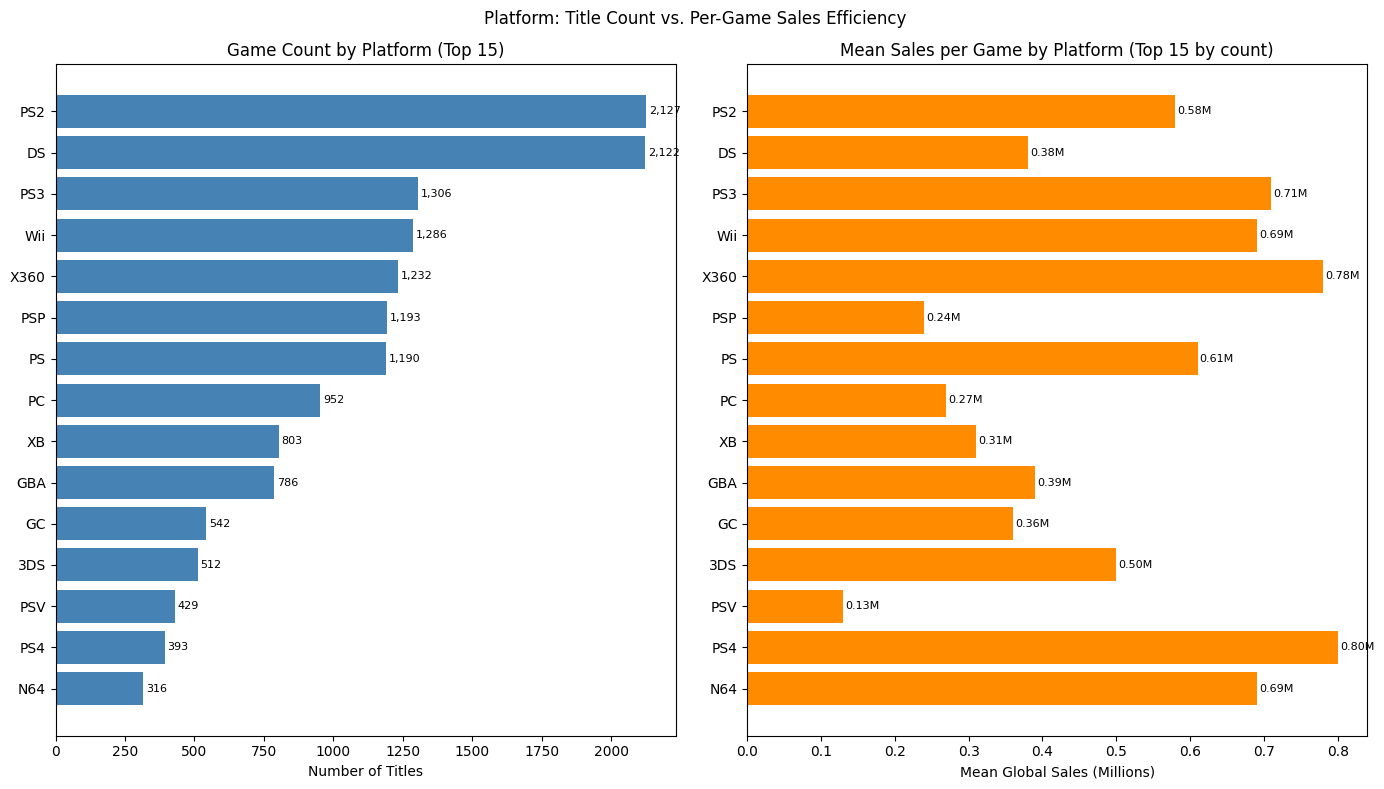

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

platform_data = summaries['platform_counts'].reset_index().head(15).sort_values('game_count')

axes[0].barh(platform_data['platform'], platform_data['game_count'], color='steelblue')
axes[0].set_xlabel('Number of Titles')
axes[0].set_title('Game Count by Platform (Top 15)')
for i, val in enumerate(platform_data['game_count']):
    axes[0].text(val + 10, i, f'{val:,}', va='center', fontsize=8)

axes[1].barh(platform_data['platform'], platform_data['mean_global_sales'], color='darkorange')
axes[1].set_xlabel('Mean Global Sales (Millions)')
axes[1].set_title('Mean Sales per Game by Platform (Top 15 by count)')
for i, val in enumerate(platform_data['mean_global_sales']):
    axes[1].text(val + 0.003, i, f'{val:.2f}M', va='center', fontsize=8)

plt.suptitle('Platform: Title Count vs. Per-Game Sales Efficiency', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** PS2 and DS lead in game count at 2,127 and 2,122 titles respectively, reflecting their long commercial lifespans and broad support from third party developers. NES (2.56M mean sales) and GB (2.62M mean sales) show the highest averages per game despite small catalog sizes, which is a survivorship artifact: only commercially significant early era titles appear in this dataset. Among modern platforms, PS4 (0.80M) and X360 (0.78M) show the strongest revenue per game. PSV stands out as an outlier with 429 titles but only 0.13M in mean sales, indicating the Vita attracted many releases that sold poorly in Western markets.

#### Q3: Which genres and platforms account for the most total global sales?

In [65]:
print("Global sales by genre (sorted by total):")
print(summaries['genre_counts'].sort_values('total_global_sales', ascending=False).to_string())
print()
print("Global sales by platform (sorted by total):")
print(summaries['platform_counts'].sort_values('total_global_sales', ascending=False).to_string())

Global sales by genre (sorted by total):
              game_count  total_global_sales  mean_global_sales
genre                                                          
Action              3307             1717.62               0.52
Sports              2306             1310.39               0.57
Shooter             1296             1041.83               0.80
Role-Playing        1483              930.90               0.63
Platform             878              825.86               0.94
Misc                1697              783.19               0.46
Racing              1225              723.69               0.59
Fighting             837              442.63               0.53
Simulation           855              388.22               0.45
Puzzle               569              240.33               0.42
Adventure           1291              233.25               0.18
Strategy             672              172.69               0.26

Global sales by platform (sorted by total):
          game_cou

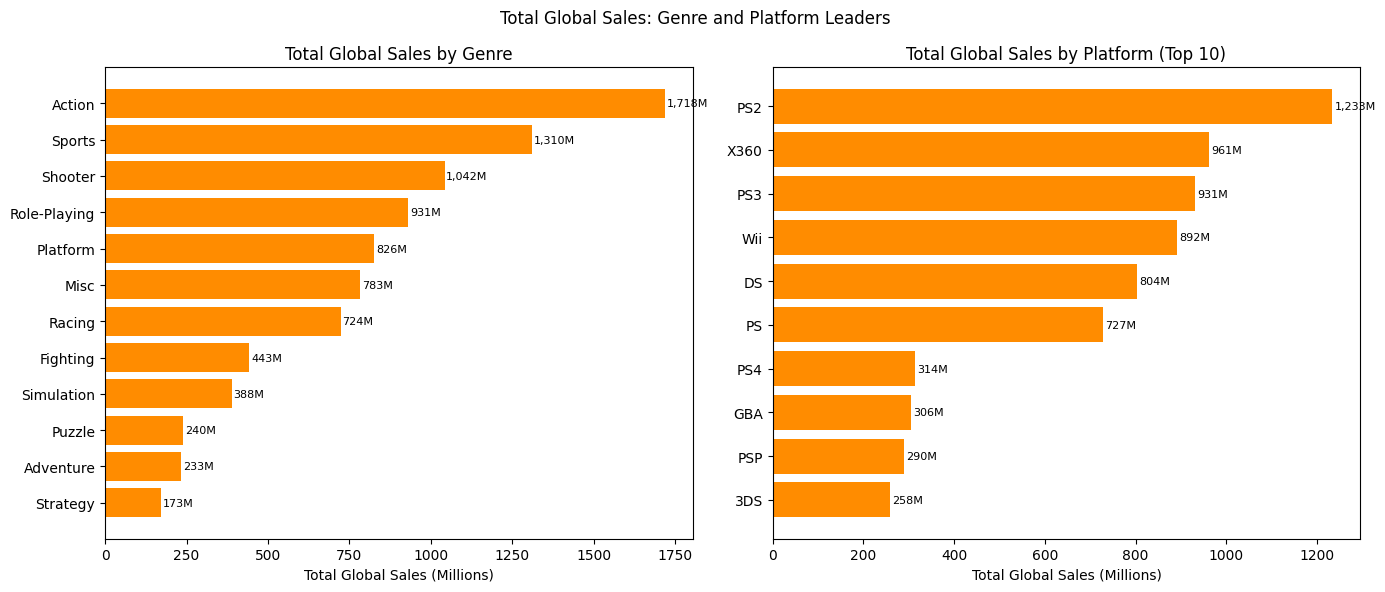

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

genre_sales = summaries['genre_counts'].sort_values('total_global_sales').reset_index()
axes[0].barh(genre_sales['genre'], genre_sales['total_global_sales'], color='darkorange')
axes[0].set_xlabel('Total Global Sales (Millions)')
axes[0].set_title('Total Global Sales by Genre')
for i, val in enumerate(genre_sales['total_global_sales']):
    axes[0].text(val + 5, i, f'{val:,.0f}M', va='center', fontsize=8)

platform_sales = (
    summaries['platform_counts']
    .sort_values('total_global_sales', ascending=False)
    .head(10)
    .sort_values('total_global_sales')
    .reset_index()
)
axes[1].barh(platform_sales['platform'], platform_sales['total_global_sales'], color='darkorange')
axes[1].set_xlabel('Total Global Sales (Millions)')
axes[1].set_title('Total Global Sales by Platform (Top 10)')
for i, val in enumerate(platform_sales['total_global_sales']):
    axes[1].text(val + 5, i, f'{val:,.0f}M', va='center', fontsize=8)

plt.suptitle('Total Global Sales: Genre and Platform Leaders', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** Action leads total global sales (1,717.62M) primarily due to its large title count rather than exceptional revenue per game. Shooter and Platform generate fewer titles but stronger sales per game (0.80M and 0.94M), making them more commercially efficient genres. Adventure generates the lowest average at 0.18M across 1,291 titles, indicating the genre is dominated by small commercial releases. Among platforms, PS2 volume drives the highest total sales (1,233.46M), while PS4 and X360 show that a smaller catalog can still generate substantial aggregate revenue through stronger average sales per title.

#### Q4: How have genre and platform patterns changed over time?

In [67]:
releases_by_year = (
    df_clean.groupby('year_of_release')['name']
    .count()
    .reset_index()
    .rename(columns={'name': 'game_count'})
)

print("Game releases by year:")
print(releases_by_year.to_string(index=False))
print()

top_genres = summaries['genre_counts'].head(5).index.tolist()
genre_by_year = (
    df_clean[df_clean['genre'].isin(top_genres)]
    .groupby(['year_of_release', 'genre'])['name']
    .count()
    .unstack(fill_value=0)
)

print("Release counts for top 5 genres by year:")
print(genre_by_year.to_string())

Game releases by year:
 year_of_release  game_count
            1980           9
            1981          46
            1982          36
            1983          17
            1984          14
            1985          14
            1986          21
            1987          16
            1988          15
            1989          17
            1990          16
            1991          41
            1992          43
            1993          60
            1994         121
            1995         219
            1996         263
            1997         289
            1998         379
            1999         338
            2000         350
            2001         482
            2002         829
            2003         775
            2004         743
            2005         934
            2006        1006
            2007        1196
            2008        1427
            2009        1426
            2010        1253
            2011        1133
            2012    

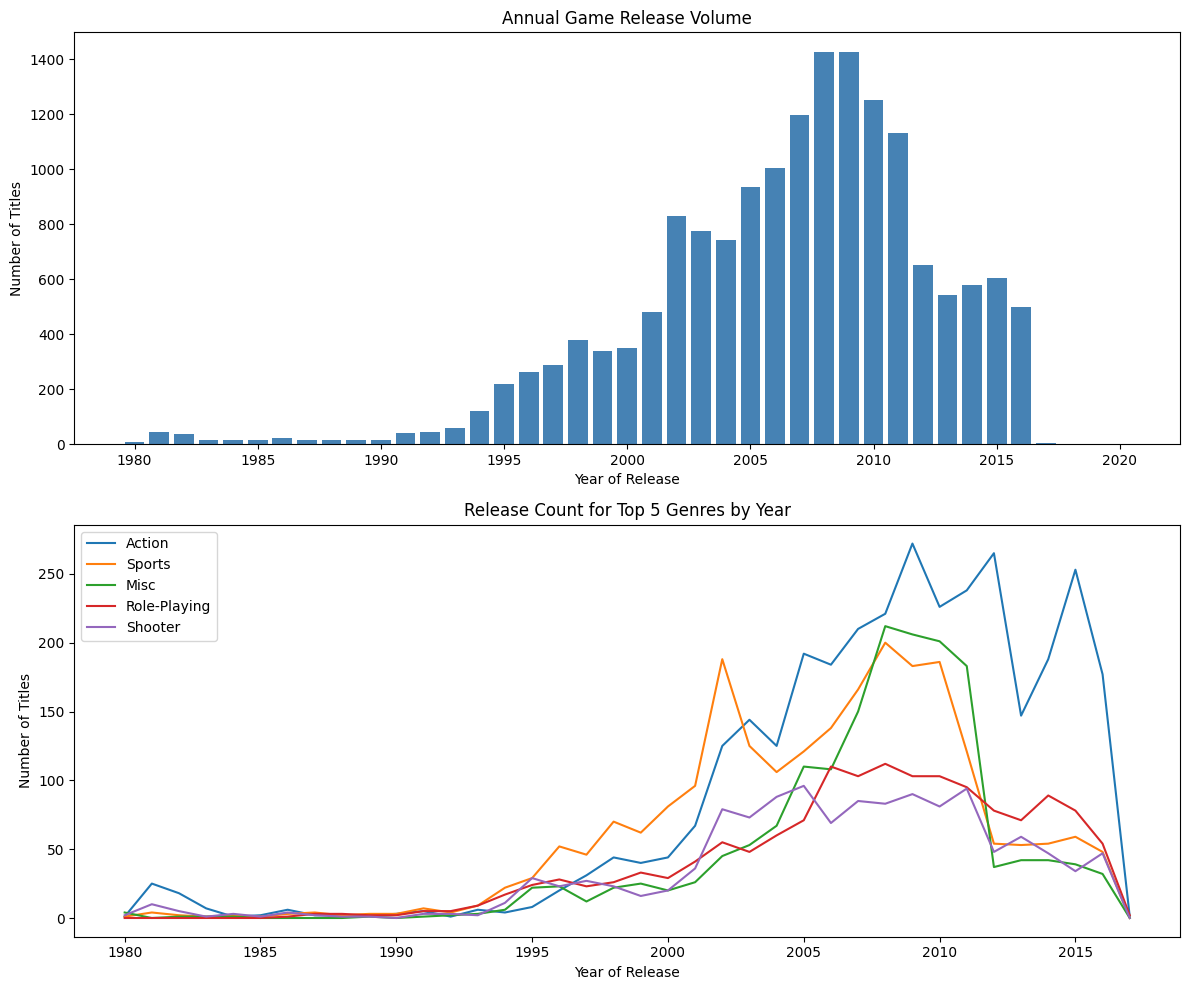

In [68]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

releases_by_year = df_clean.groupby('year_of_release')['name'].count().reset_index()
releases_by_year.columns = ['year_of_release', 'game_count']
axes[0].bar(releases_by_year['year_of_release'], releases_by_year['game_count'], color='steelblue', width=0.8)
axes[0].set_xlabel('Year of Release')
axes[0].set_ylabel('Number of Titles')
axes[0].set_title('Annual Game Release Volume')

top_genres = summaries['genre_counts'].head(5).index.tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
genre_year = (
    df_clean[df_clean['genre'].isin(top_genres)]
    .groupby(['year_of_release', 'genre'])['name']
    .count()
    .unstack(fill_value=0)
)
for genre, color in zip(top_genres, colors):
    axes[1].plot(genre_year.index, genre_year[genre], label=genre, color=color, linewidth=1.5)
axes[1].set_xlabel('Year of Release')
axes[1].set_ylabel('Number of Titles')
axes[1].set_title('Release Count for Top 5 Genres by Year')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:** Release volume grew from single digits in 1980 to a peak of 1,427 titles in 2008, then fell sharply after 2011. This reflects the industry shift toward releasing fewer titles with higher budgets and the rise of digital distribution, which is largely absent from this dataset. Action overtook Sports as the dominant genre around 2005 and remained at the top thereafter. The Sports surge in the early 2000s reflects annual franchise publishing cycles by EA Sports and 2K that contracted after 2011. The Misc genre spike from 2007 to 2011 corresponds to the Wii casual gaming era. Release counts drop to nearly zero after 2016 due to incomplete data collection rather than an actual market contraction.

#### Q5: How are global sales distributed, and are they concentrated among a small number of hit games?

In [69]:
sales = df_clean['global_sales']

print("Global sales distribution (millions of units):")
print(f"  Mean:   {sales.mean():.3f}")
print(f"  Median: {sales.median():.3f}")
print(f"  Std:    {sales.std():.3f}")
print(f"  Min:    {sales.min():.3f}")
print(f"  Max:    {sales.max():.3f}")
print()

bins   = [0, 0.1, 1.0, 10.0, float('inf')]
labels = ['Low (<0.1M)', 'Moderate (0.1-1M)', 'High (1-10M)', 'Blockbuster (>10M)']
df_clean['sales_tier'] = pd.cut(sales, bins=bins, labels=labels)

tier_counts = df_clean['sales_tier'].value_counts().reindex(labels)
tier_pct    = (tier_counts / len(df_clean) * 100).round(1)

print("Sales tier breakdown:")
for tier, count, pct in zip(labels, tier_counts, tier_pct):
    print(f"  {tier}: {count:,} games ({pct}%)")

print()
total_sales  = sales.sum()
top10_sales  = sales.nlargest(10).sum()
top100_sales = sales.nlargest(100).sum()
print(f"Top 10 games account for  {top10_sales / total_sales * 100:.1f}% of total global sales")
print(f"Top 100 games account for {top100_sales / total_sales * 100:.1f}% of total global sales")

Global sales distribution (millions of units):
  Mean:   0.537
  Median: 0.170
  Std:    1.560
  Min:    0.010
  Max:    82.530

Sales tier breakdown:
  Low (<0.1M): 6,190 games (37.7%)
  Moderate (0.1-1M): 8,193 games (49.9%)
  High (1-10M): 1,971 games (12.0%)
  Blockbuster (>10M): 62 games (0.4%)

Top 10 games account for  4.2% of total global sales
Top 100 games account for 16.6% of total global sales


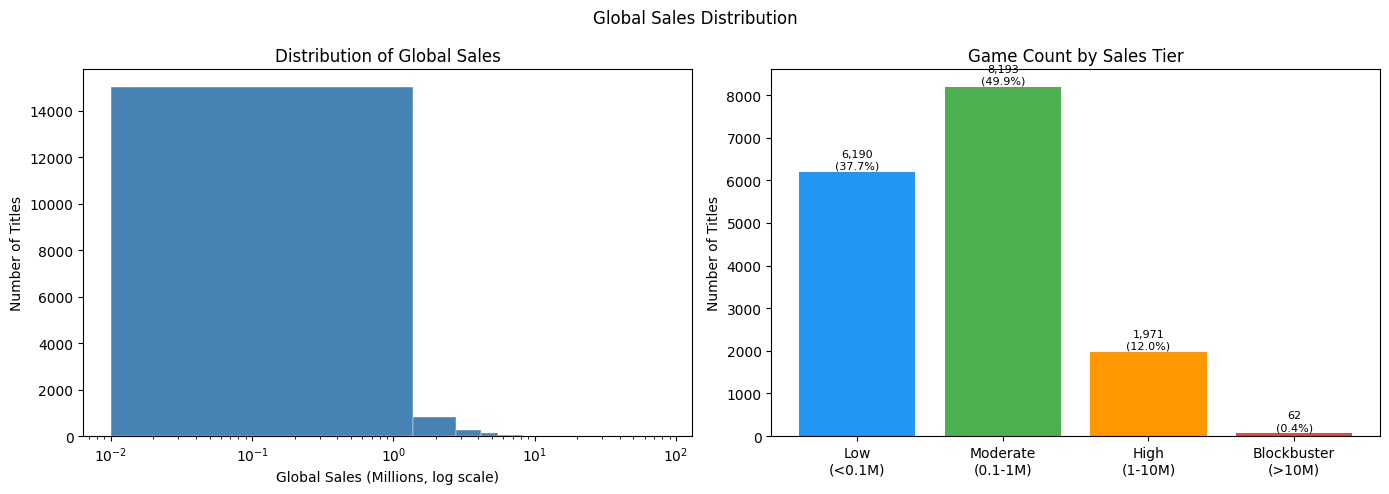

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['global_sales'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xscale('log')
axes[0].set_xlabel('Global Sales (Millions, log scale)')
axes[0].set_ylabel('Number of Titles')
axes[0].set_title('Distribution of Global Sales')

tier_keys = ['Low (<0.1M)', 'Moderate (0.1-1M)', 'High (1-10M)', 'Blockbuster (>10M)']
tier_labels = ['Low\n(<0.1M)', 'Moderate\n(0.1-1M)', 'High\n(1-10M)', 'Blockbuster\n(>10M)']
counts = df_clean['sales_tier'].value_counts().reindex(tier_keys)
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
axes[1].bar(tier_labels, counts, color=bar_colors)
axes[1].set_ylabel('Number of Titles')
axes[1].set_title('Game Count by Sales Tier')
for i, val in enumerate(counts):
    axes[1].text(i, val + 80, f'{val:,}\n({val / len(df_clean) * 100:.1f}%)', ha='center', fontsize=8)

plt.suptitle('Global Sales Distribution', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** The global sales distribution is heavily skewed to the right: the median title sells 0.17M units while the mean is 0.54M, a ratio that signals extreme concentration at the top. Nearly 88% of titles sell fewer than 1M copies, and only 62 games (0.4%) qualify as blockbusters above 10M. Despite this, the top 10 titles account for only 4.2% of total global sales and the top 100 for 16.6%, meaning the long tail of moderate sellers collectively contributes most of the market's commercial volume. For an AI development tool targeting actionable market benchmarks, the Moderate tier (0.1M to 1M) represents the typical commercial outcome for a released title.

#### Q6: How do critic scores and user scores compare?

In [71]:
reviewed = df_clean.dropna(subset=['critic_score', 'user_score']).copy()
reviewed['user_score_scaled'] = reviewed['user_score'] * 10

print(f"Records with both scores: {len(reviewed):,}")
print()
print("Critic score (0-100 scale):")
print(f"  Mean:   {reviewed['critic_score'].mean():.2f}")
print(f"  Median: {reviewed['critic_score'].median():.2f}")
print(f"  Std:    {reviewed['critic_score'].std():.2f}")
print()
print("User score (scaled to 0-100 for comparison):")
print(f"  Mean:   {reviewed['user_score_scaled'].mean():.2f}")
print(f"  Median: {reviewed['user_score_scaled'].median():.2f}")
print(f"  Std:    {reviewed['user_score_scaled'].std():.2f}")
print()

reviewed['score_gap'] = reviewed['critic_score'] - reviewed['user_score_scaled']
print(f"Mean critic-user gap: {reviewed['score_gap'].mean():.2f} points")
print(f"  Positive = critics rated higher than users")
print(f"  Negative = users rated higher than critics")
print()

print("Mean critic vs user score gap by genre:")
genre_gap = (
    reviewed.groupby('genre')['score_gap']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)
print(genre_gap.to_string())

Records with both scores: 6,893

Critic score (0-100 scale):
  Mean:   70.26
  Median: 72.00
  Std:    13.86

User score (scaled to 0-100 for comparison):
  Mean:   71.85
  Median: 75.00
  Std:    14.39

Mean critic-user gap: -1.59 points
  Positive = critics rated higher than users
  Negative = users rated higher than critics

Mean critic vs user score gap by genre:
genre
Sports          3.09
Shooter         0.08
Strategy       -0.28
Misc           -0.99
Racing         -1.49
Puzzle         -1.81
Simulation     -1.93
Action         -3.16
Fighting       -3.33
Role-Playing   -3.39
Platform       -3.77
Adventure      -5.42


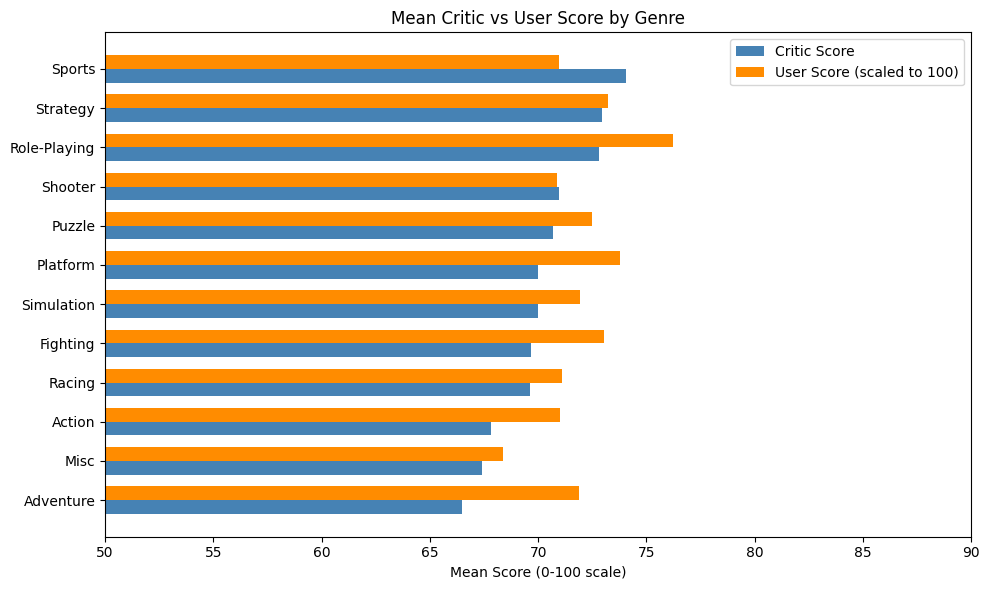

In [72]:
reviewed_scores = df_clean.dropna(subset=['critic_score', 'user_score']).copy()
reviewed_scores['user_score_scaled'] = reviewed_scores['user_score'] * 10

genre_compare = reviewed_scores.groupby('genre').agg(
    mean_critic=('critic_score', 'mean'),
    mean_user=('user_score_scaled', 'mean'),
).round(2).sort_values('mean_critic', ascending=True)

y = range(len(genre_compare))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([i - width / 2 for i in y], genre_compare['mean_critic'], width, label='Critic Score', color='steelblue')
ax.barh([i + width / 2 for i in y], genre_compare['mean_user'], width, label='User Score (scaled to 100)', color='darkorange')
ax.set_yticks(list(y))
ax.set_yticklabels(genre_compare.index)
ax.set_xlabel('Mean Score (0-100 scale)')
ax.set_title('Mean Critic vs User Score by Genre')
ax.set_xlim(50, 90)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Critics and users track closely on average: mean critic score is 70.26 versus 71.85 (scaled to 100) for users, a gap of only 1.59 points. Patterns at the genre level reveal meaningful divergences in evaluation standards. Sports is the only genre where critics rate consistently higher than users (a gap of 3.09 points), possibly reflecting critic appreciation for technical execution alongside player fatigue from annual franchise releases. Adventure shows the largest gap in favor of users at 5.42 points, suggesting players assign more value to narrative experience than critics do. Role Playing and Platform show similar gaps in the 3 to 4 point range. These systematic differences by genre carry direct implications for calibrating what quality means when targeting a specific audience.

#### Q7: Do higher rated games tend to have higher global sales?

In [73]:
critic_sales_corr = reviewed['critic_score'].corr(reviewed['global_sales']).round(3)
user_sales_corr   = reviewed['user_score'].corr(reviewed['global_sales']).round(3)

print("Pearson correlation with global sales:")
print(f"  Critic score: {critic_sales_corr}")
print(f"  User score:   {user_sales_corr}")
print()
print("Note: correlation measures linear association only.")
print("Given the heavy sales skew, a low correlation does not rule out")
print("a relationship between quality and commercial success.")

Pearson correlation with global sales:
  Critic score: 0.237
  User score:   0.088

Note: correlation measures linear association only.
Given the heavy sales skew, a low correlation does not rule out
a relationship between quality and commercial success.


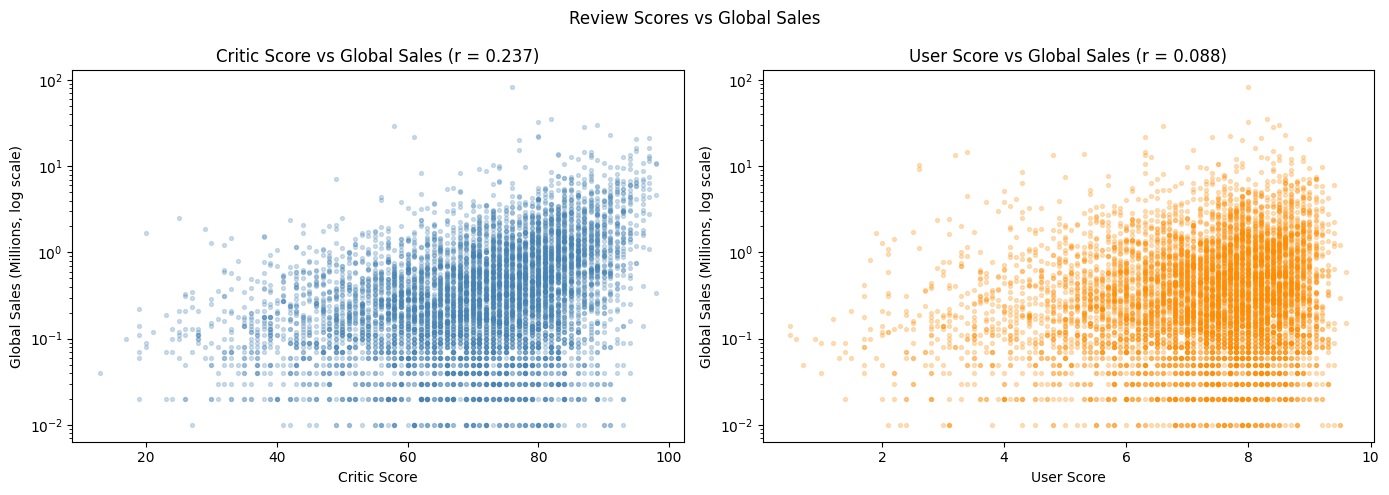

In [74]:
reviewed_scatter = df_clean.dropna(subset=['critic_score', 'user_score']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(reviewed_scatter['critic_score'], reviewed_scatter['global_sales'],
                alpha=0.25, s=8, color='steelblue')
axes[0].set_yscale('log')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Global Sales (Millions, log scale)')
axes[0].set_title('Critic Score vs Global Sales (r = 0.237)')

axes[1].scatter(reviewed_scatter['user_score'], reviewed_scatter['global_sales'],
                alpha=0.25, s=8, color='darkorange')
axes[1].set_yscale('log')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Global Sales (Millions, log scale)')
axes[1].set_title('User Score vs Global Sales (r = 0.088)')

plt.suptitle('Review Scores vs Global Sales', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** Critic score has a modest positive correlation with global sales (r = 0.237), while user score is nearly uncorrelated (r = 0.088). The scatter plots show no clean linear relationship: many highly scored games sell modestly, and some low scoring games sell well. Commercial success is driven more by franchise strength, marketing investment, and platform installed base than by review scores alone. The stronger correlation for critic score compared to user scores may reflect that critical coverage drives consumer awareness more than pure quality perception does. For an AI game development tool, this suggests critic score is a useful but limited signal. Market positioning and genre selection likely matter more than quality ratings when predicting commercial outcomes.

The seven questions above establish the market context. Section 7 presents four standalone polished charts that distill the most significant findings for presentation and reporting.

## 7. Visualizations

The following four charts present the most significant findings from the exploratory analysis in standalone, presentation ready format. Each is saved to `outputs/figures/` for use in reports or documentation.

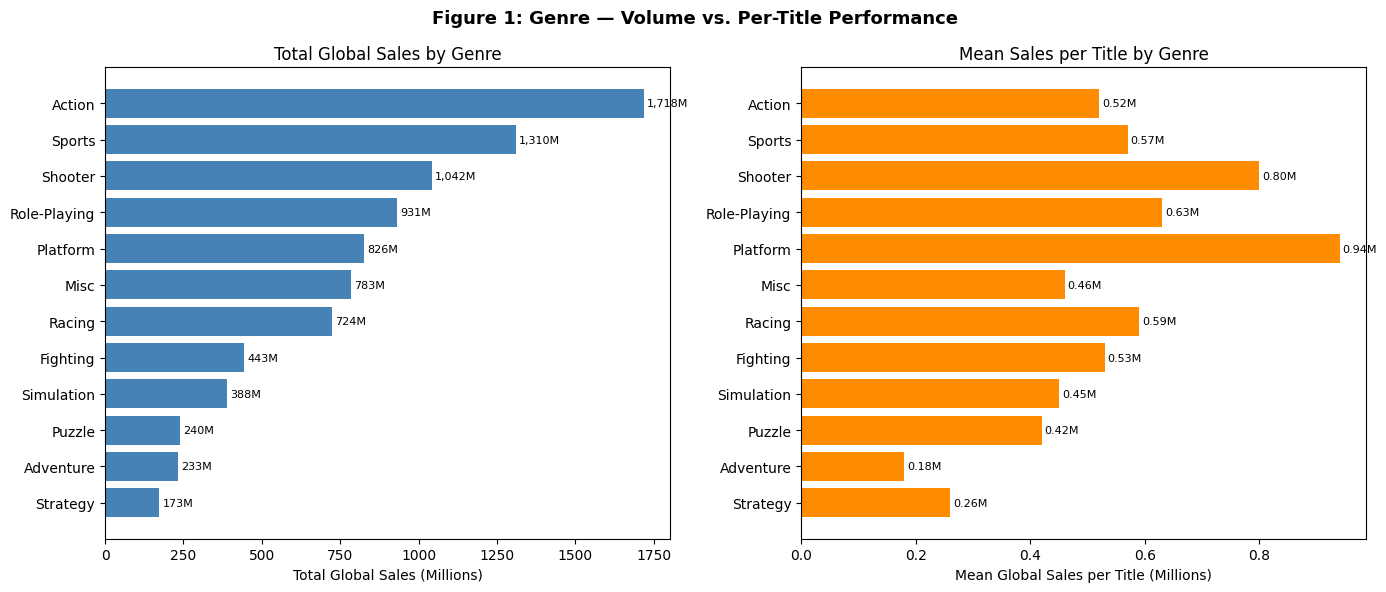

Saved: outputs/figures/fig1_genre_market_overview.png


In [75]:
import os
os.makedirs('../outputs/figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

genre_data = summaries['genre_counts'].sort_values('total_global_sales').reset_index()

bars = axes[0].barh(genre_data['genre'], genre_data['total_global_sales'], color='steelblue')
axes[0].set_xlabel('Total Global Sales (Millions)')
axes[0].set_title('Total Global Sales by Genre')
for bar, val in zip(bars, genre_data['total_global_sales']):
    axes[0].text(val + 10, bar.get_y() + bar.get_height() / 2,
                 f'{val:,.0f}M', va='center', fontsize=8)

bars2 = axes[1].barh(genre_data['genre'], genre_data['mean_global_sales'], color='darkorange')
axes[1].set_xlabel('Mean Global Sales per Title (Millions)')
axes[1].set_title('Mean Sales per Title by Genre')
for bar, val in zip(bars2, genre_data['mean_global_sales']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}M', va='center', fontsize=8)

fig.suptitle('Figure 1: Genre — Volume vs. Per-Title Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig1_genre_market_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/fig1_genre_market_overview.png")

Action leads in total global sales driven by title volume, but Platform and Shooter generate higher revenue per release. This split between volume and efficiency signals that genre selection matters more commercially than raw catalog size.

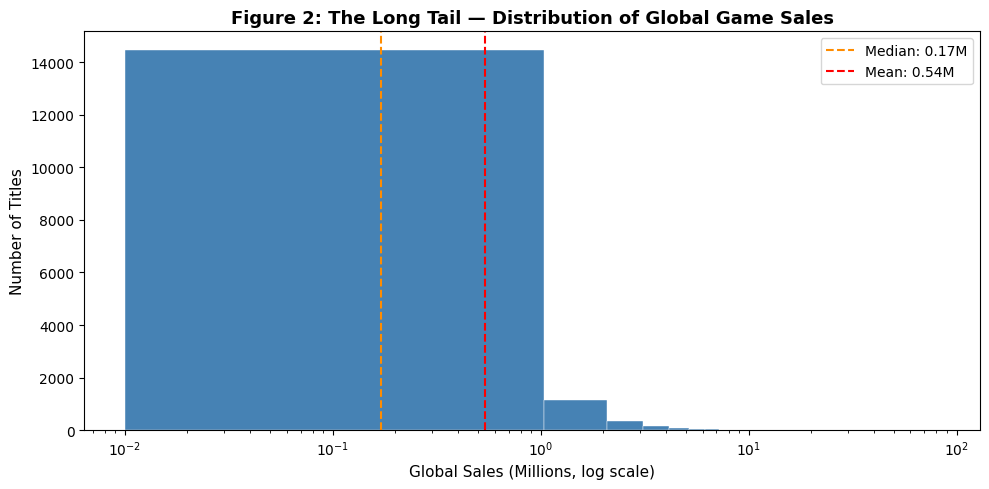

Saved: outputs/figures/fig2_sales_distribution.png


In [76]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_clean['global_sales'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xscale('log')
ax.set_xlabel('Global Sales (Millions, log scale)', fontsize=11)
ax.set_ylabel('Number of Titles', fontsize=11)
ax.axvline(df_clean['global_sales'].median(), color='darkorange', linestyle='--', linewidth=1.5,
           label=f"Median: {df_clean['global_sales'].median():.2f}M")
ax.axvline(df_clean['global_sales'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean: {df_clean['global_sales'].mean():.2f}M")
ax.legend(fontsize=10)
ax.set_title('Figure 2: The Long Tail — Distribution of Global Game Sales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig2_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/fig2_sales_distribution.png")

The mean (0.54M) sits far above the median (0.17M), confirming the long tail structure: a small number of blockbuster titles pull the average up while the vast majority of games sell modestly. The typical commercial outcome for a released game falls in the 0.1M to 1M range.

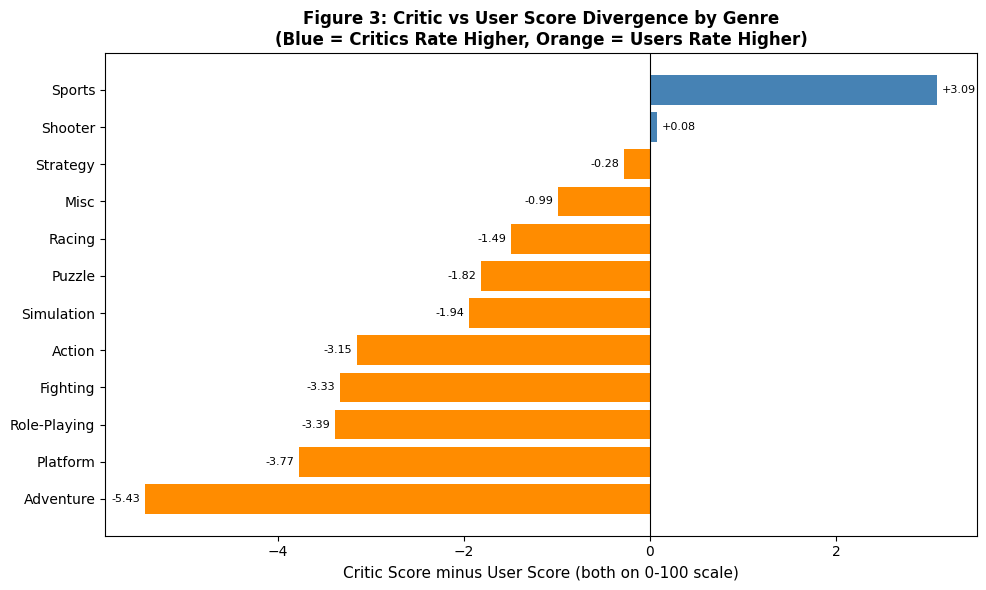

Saved: outputs/figures/fig3_score_divergence.png


In [77]:
reviewed_fig = df_clean.dropna(subset=['critic_score', 'user_score']).copy()
reviewed_fig['user_score_scaled'] = reviewed_fig['user_score'] * 10

genre_fig = reviewed_fig.groupby('genre').agg(
    mean_critic=('critic_score', 'mean'),
    mean_user=('user_score_scaled', 'mean'),
).round(2)
genre_fig['gap'] = genre_fig['mean_critic'] - genre_fig['mean_user']
genre_fig = genre_fig.sort_values('gap')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if g >= 0 else 'darkorange' for g in genre_fig['gap']]
ax.barh(genre_fig.index, genre_fig['gap'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Critic Score minus User Score (both on 0-100 scale)', fontsize=11)
for i, (genre, row) in enumerate(genre_fig.iterrows()):
    offset = 0.05 if row['gap'] >= 0 else -0.05
    ha = 'left' if row['gap'] >= 0 else 'right'
    ax.text(row['gap'] + offset, i, f"{row['gap']:+.2f}", va='center', ha=ha, fontsize=8)
ax.set_title(
    'Figure 3: Critic vs User Score Divergence by Genre\n(Blue = Critics Rate Higher, Orange = Users Rate Higher)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig3_score_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/fig3_score_divergence.png")

Sports is the only genre where critics score consistently higher than users. Adventure shows the largest gap in favor of users at 5.42 points, indicating players value narrative experience more than critics do. This divergence is a useful signal for evaluating quality targets by genre.

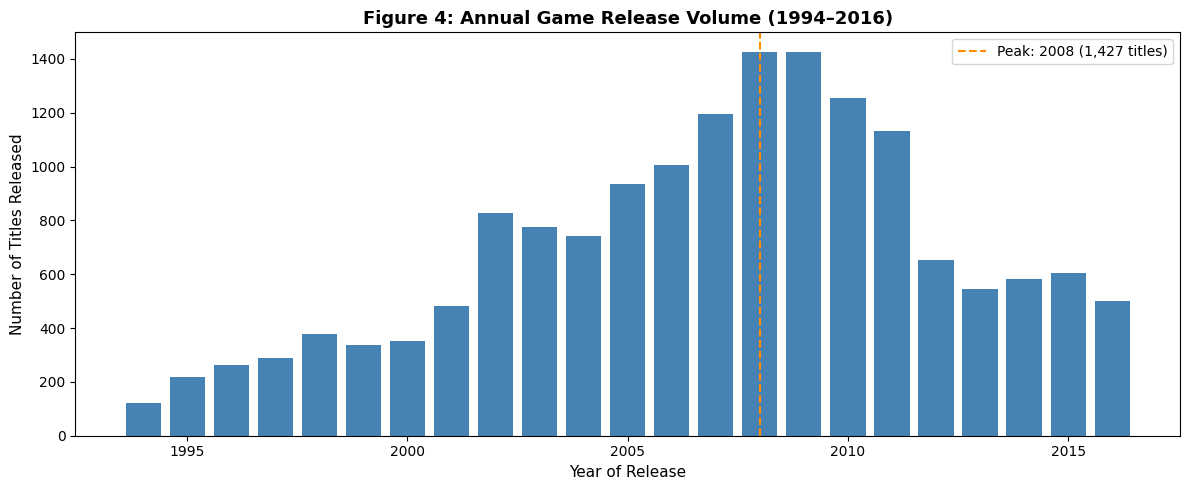

Saved: outputs/figures/fig4_release_volume.png


In [78]:
releases_fig = df_clean.groupby('year_of_release')['name'].count().reset_index()
releases_fig.columns = ['year', 'count']
releases_fig = releases_fig[(releases_fig['year'] >= 1994) & (releases_fig['year'] <= 2016)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(releases_fig['year'], releases_fig['count'], color='steelblue', width=0.8)
ax.set_xlabel('Year of Release', fontsize=11)
ax.set_ylabel('Number of Titles Released', fontsize=11)
ax.axvline(2008, color='darkorange', linestyle='--', linewidth=1.5,
           label='Peak: 2008 (1,427 titles)')
ax.legend(fontsize=10)
ax.set_title('Figure 4: Annual Game Release Volume (1994–2016)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig4_release_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/fig4_release_volume.png")

Release volume peaked in 2008 and declined sharply after 2011, reflecting the industry shift toward releasing fewer titles with higher budgets and the rise of digital distribution that is largely absent from this dataset.

## 8. Summary and Interpretation

## 9. Responsible Data Handling and Bias Awareness

## 10. Future Integration with AI Game Director Studio